In [3]:
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [6]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
df[df['species']!='setosa']

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
df['species']=df['species'].map({'setosasetosa':0, 'virginicasetosa':1})

In [10]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,NaN
1,4.9,3.0,1.4,0.2,NaN
2,4.7,3.2,1.3,0.2,NaN
3,4.6,3.1,1.5,0.2,NaN
4,5.0,3.6,1.4,0.2,NaN


In [11]:
#Split dataset into independent and dependent featurs

In [12]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [13]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [14]:
y

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
145   NaN
146   NaN
147   NaN
148   NaN
149   NaN
Name: species, Length: 150, dtype: float64

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()

In [ ]:
from sklearn.model_selection import GridSearchCV
Parameter={'penalty':['11','12','elasticnet'],'C':[1,2,3,4,5,6,10,20,30,40],'max_iter':[100,200,300 ]}

In [22]:
classifier_regressor= GridSearchCV(classifier,param_grid =Parameter,scoring='accuracy',cv=5)

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [52]:
print(df.columns.tolist())

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [65]:
classifier_regressor.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, None], 'n_estimators': [50, 100]})

In [66]:
print(classifier_regressor.best_params_)

{'max_depth': 3, 'n_estimators': 50}


In [67]:
print(classifier_regressor.best_score_)

1.0


In [68]:
#Prediction 
y_pred=classifier_regressor.predict(X_test)

In [69]:
#Accuracy_score
from sklearn.metrics import accuracy_score,classification_report

In [70]:
score=accuracy_score(y_pred,y_test)
print(score)

1.0


In [71]:
classification_report(y_pred,y_test)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        38\n\n    accuracy                           1.00        38\n   macro avg       1.00      1.00      1.00        38\nweighted avg       1.00      1.00      1.00        38\n'

(<seaborn.axisgrid.PairGrid at 0x1d65273b970>, 'sepal_width')

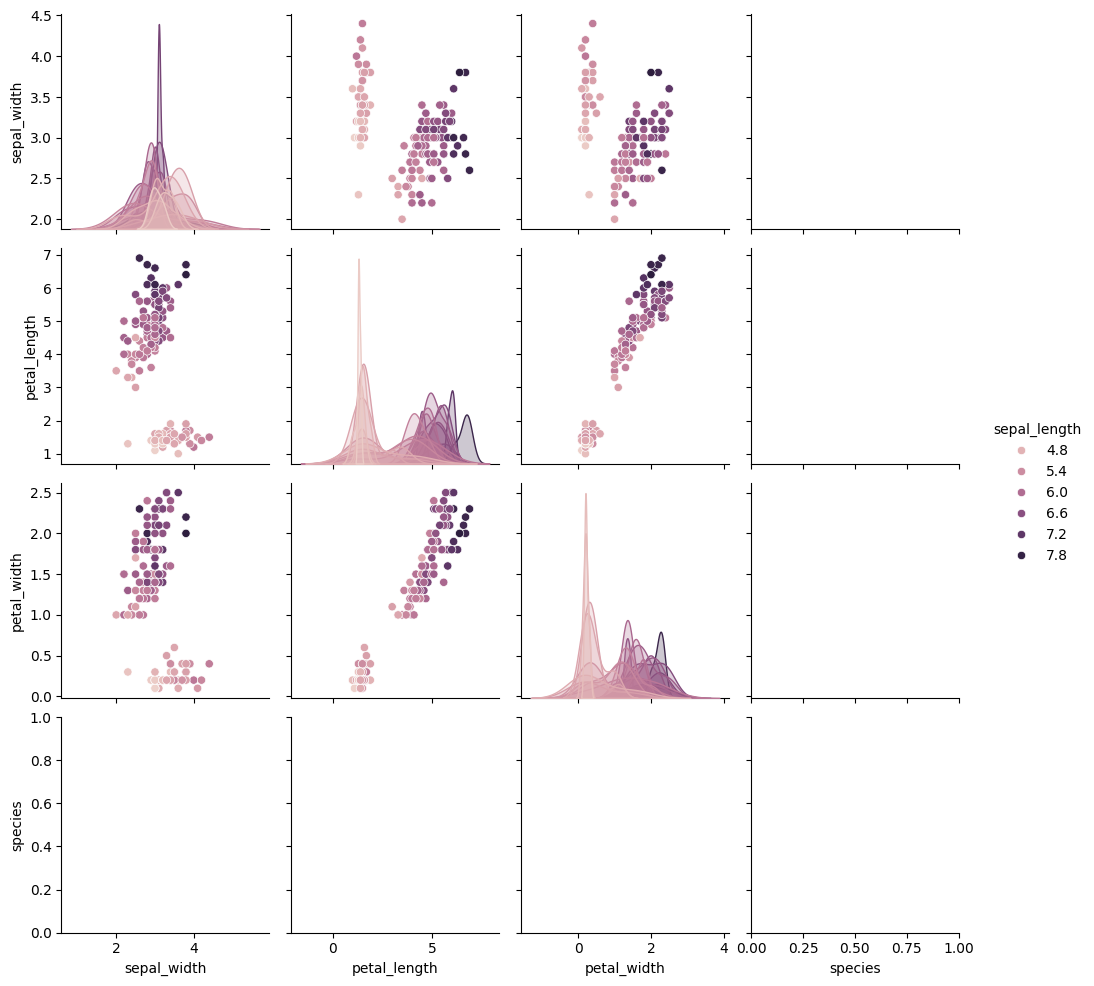

In [76]:
#EDA
sns.pairplot(df,hue ='sepal_length'),'sepal_width'

In [72]:
df.corr

<bound method DataFrame.corr of      sepal_length  sepal_width  petal_length  petal_width  species
0             5.1          3.5           1.4          0.2      NaN
1             4.9          3.0           1.4          0.2      NaN
2             4.7          3.2           1.3          0.2      NaN
3             4.6          3.1           1.5          0.2      NaN
4             5.0          3.6           1.4          0.2      NaN
..            ...          ...           ...          ...      ...
145           6.7          3.0           5.2          2.3      NaN
146           6.3          2.5           5.0          1.9      NaN
147           6.5          3.0           5.2          2.0      NaN
148           6.2          3.4           5.4          2.3      NaN
149           5.9          3.0           5.1          1.8      NaN

[150 rows x 5 columns]>